# DCRouter - Training

This notebook demonstrates how to train the **DCRouter** (Dual Contrastive Router).

## Overview

DCRouter uses dual contrastive learning with a mDEBERTa transformer backbone to route queries.
It learns to distinguish between good and bad LLM matches using contrastive loss.

**Key Features**:
- Transformer-based (mDEBERTa) backbone
- Dual contrastive loss for better discrimination
- Cluster-based negative sampling
- State-of-the-art routing performance

## 1. Environment Setup

In [1]:
# Install required packages (for Colab)
!git clone https://github.com/ulab-uiuc/LLMRouter.git
%cd LLMRouter
!pip install -e .
!pip install transformers torch matplotlib

Cloning into 'LLMRouter'...
remote: Enumerating objects: 6017, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 6017 (delta 105), reused 96 (delta 90), pack-reused 5837 (from 2)
Receiving objects: 100% (6017/6017), 89.41 MiB | 53.57 MiB/s, done.
Resolving deltas: 100% (2946/2946), done.
Updating files: 100% (288/288), done.
/home/zhongjie/LLMRouter
Obtaining file:///home/zhongjie/LLMRouter
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached sentencepiece-0.2.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached gradio-6.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached litellm-1

In [2]:
import os
os.environ['OPENAI_API_KEY'] = 'your-key'
os.environ['ANTHROPIC_API_KEY'] = 'your-key'
# Or for multiple keys:
os.environ['API_KEYS'] = '["key1", "key2"]'

In [3]:
import torch
from llmrouter.models.routerdc import DCRouter, DCTrainer   
from llmrouter.utils import setup_environment

setup_environment()

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Configuration

DCRouter uses the following configuration parameters:

| Parameter | Description | Default |
|-----------|-------------|--------|
| `hidden_state_dim` | Backbone hidden dimension | 768 |
| `similarity_function` | Similarity metric | "cos" |
| `batch_size` | Training batch size | 32 |
| `training_steps` | Total training steps | 500 |
| `learning_rate` | Learning rate | 5e-5 |
| `top_k` | Top-k LLMs for positive samples | 3 |
| `last_k` | Last-k LLMs for negative samples | 3 |
| `temperature` | Softmax temperature | 1.0 |

In [4]:
import yaml

CONFIG_PATH = "configs/model_config_train/dcrouter.yaml"

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print("Current Configuration:")
print("=" * 50)
print(yaml.dump(config, default_flow_style=False))

Current Configuration:
data_path:
  llm_data: data/example_data/llm_candidates/default_llm.json
  llm_embedding_data: data/example_data/llm_candidates/default_llm_embeddings.json
  preprocessed_dir: data/dcrouter_preprocessed
  query_data_test: data/example_data/query_data/default_query_test.jsonl
  query_data_train: data/example_data/query_data/default_query_train.jsonl
  routing_data_test: data/example_data/routing_data/default_routing_test_data.jsonl
  routing_data_train: data/example_data/routing_data/default_routing_train_data.jsonl
hparam:
  H: 3
  batch_size: 32
  cluster_loss_weight: 1.0
  device: cpu
  eval_steps: 50
  gradient_accumulation: 1
  hidden_state_dim: 768
  inference_batch_size: 64
  inference_temperature: 1.0
  last_k: 3
  learning_rate: 5.0e-05
  max_test_samples: 500
  n_clusters: 3
  sample_loss_weight: 0.0
  seed: 1
  similarity_function: cos
  source_max_token_len: 512
  target_max_token_len: 512
  temperature: 1.0
  top_k: 3
  training_steps: 500
metric:
  w

## 3. Initialize Router

In [5]:
# Initialize DCRouter with configuration
router = DCRouter(yaml_path=CONFIG_PATH)

print("Router initialized successfully!")
print(f"Number of training samples: {len(router.routing_data_train)}")
print(f"Number of LLM candidates: {len(router.llm_data)}")
print(f"LLM candidates: {list(router.llm_data.keys())}")
print(f"Backbone model: {config['model_path'].get('backbone_model', 'microsoft/mdeberta-v3-base')}")

Router initialized successfully!
Number of training samples: 50544
Number of LLM candidates: 7
LLM candidates: ['qwen2.5-7b-instruct', 'llama-3.1-8b-instruct', 'mistral-7b-instruct-v0.3', 'llama-3.3-nemotron-super-49b-v1', 'llama3-70b-instruct', 'mixtral-8x7b-instruct-v0.1', 'mixtral-8x22b-instruct-v0.1']
Backbone model: microsoft/mdeberta-v3-base


## 4. Training

In [6]:
# Initialize trainer
trainer = DCTrainer(router=router, device=device)

print("Trainer initialized!")
print(f"Device: {device}")
print(f"Save dir: {trainer.save_dir}")
print(f"Final model path: {trainer.final_model_path}")

Trainer initialized!
Device: cuda
Save dir: /home/zhongjie/LLMRouter/saved_models/dcrouter
Final model path: /home/zhongjie/LLMRouter/saved_models/dcrouter/dcrouter_model.pth


In [7]:
# Train the model
print("Starting training...")
print("=" * 50)
print("Note: DCRouter training uses dual contrastive learning.")
print("This may take some time depending on your hardware.")
print("=" * 50)

trainer.train()

print("=" * 50)
print("Training completed!")

Starting training...
Note: DCRouter training uses dual contrastive learning.
This may take some time depending on your hardware.


Training: 100%|██████████| 500/500 [17:54<00:00,  2.15s/it, step=499, loss=3.4797]  


Training completed!


## 5. Model Verification

In [8]:
# Verify the trained model
import torch

# Load saved model
model_path = trainer.final_model_path
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location='cpu')
    print(f"Model loaded from: {model_path}")
    print(f"Checkpoint keys: {checkpoint.keys() if isinstance(checkpoint, dict) else 'state_dict'}")
else:
    print(f"Model not found at: {model_path}")

Model loaded from: /home/zhongjie/LLMRouter/saved_models/dcrouter/dcrouter_model.pth
Checkpoint keys: odict_keys(['backbone.embeddings.word_embeddings.weight', 'backbone.embeddings.LayerNorm.weight', 'backbone.embeddings.LayerNorm.bias', 'backbone.encoder.layer.0.attention.self.query_proj.weight', 'backbone.encoder.layer.0.attention.self.query_proj.bias', 'backbone.encoder.layer.0.attention.self.key_proj.weight', 'backbone.encoder.layer.0.attention.self.key_proj.bias', 'backbone.encoder.layer.0.attention.self.value_proj.weight', 'backbone.encoder.layer.0.attention.self.value_proj.bias', 'backbone.encoder.layer.0.attention.output.dense.weight', 'backbone.encoder.layer.0.attention.output.dense.bias', 'backbone.encoder.layer.0.attention.output.LayerNorm.weight', 'backbone.encoder.layer.0.attention.output.LayerNorm.bias', 'backbone.encoder.layer.0.intermediate.dense.weight', 'backbone.encoder.layer.0.intermediate.dense.bias', 'backbone.encoder.layer.0.output.dense.weight', 'backbone.encode

In [9]:
# Test prediction
test_query = {"query": "What is the capital of France?"}
result = router.route_single(test_query)

print(f"Test query: {test_query['query']}")
print(f"Routed to: {result['model_name']}")

Test query: What is the capital of France?
Routed to: llama-3.1-8b-instruct


## 6. Training Curve Analysis

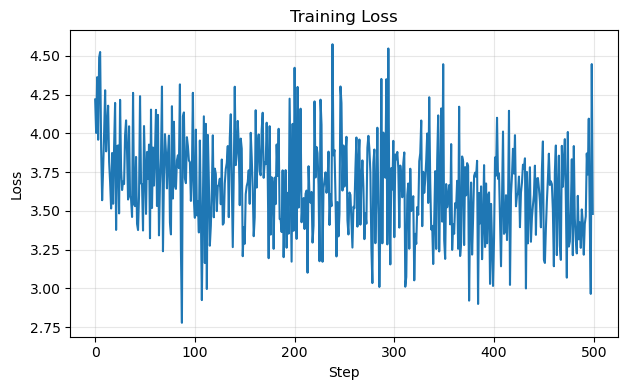

In [10]:
import matplotlib.pyplot as plt

# If training logs are available, plot them
if hasattr(trainer, 'loss_history') and trainer.loss_history:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(trainer.loss_history)
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not available for plotting.")

## Summary

In this notebook, we:

1. **Loaded Configuration**: Set up DCRouter with YAML configuration
2. **Initialized Router**: Created DCRouter with mDEBERTa backbone
3. **Trained Model**: Used dual contrastive learning
4. **Verified Model**: Tested routing with sample queries

**Key Takeaways**:
- DCRouter uses transformer-based embeddings
- Contrastive learning helps distinguish good/bad LLM matches
- GPU training recommended for faster convergence

**Next Steps**:
- Use next part of notebook for inference
- Experiment with different temperature values

# DCRouter - Inference

This part of notebook demonstrates how to use a trained **DCRouter** for inference.

## 1. Environment Setup

## 2. Load Trained Router

In [11]:
CONFIG_PATH = "configs/model_config_train/dcrouter.yaml"

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

config['model_path']['load_model_path'] = config['model_path']['save_model_path']

INFERENCE_CONFIG_PATH = "configs/model_config_test/dcrouter_inference.yaml"
os.makedirs(os.path.dirname(INFERENCE_CONFIG_PATH), exist_ok=True)

with open(INFERENCE_CONFIG_PATH, 'w') as f:
    yaml.dump(config, f)

router = DCRouter(yaml_path=INFERENCE_CONFIG_PATH)
print(f"Router loaded with {len(router.llm_data)} LLM candidates")

Router loaded with 7 LLM candidates


## 3. Query Routing

In [12]:
EXAMPLE_QUERIES = [
    {"query": "What is the capital of France?"},
    {"query": "Solve the equation: 2x + 5 = 15"},
    {"query": "Write a Python function to check if a number is prime."},
    {"query": "Explain quantum computing in simple terms."},
    {"query": "What are the implications of climate change on agriculture?"},
]

print("Routing Results:")
print("=" * 70)

for i, query in enumerate(EXAMPLE_QUERIES, 1):
    result = router.route_single(query)
    print(f"{i}. {query['query'][:55]}...")
    print(f"   Routed to: {result['model_name']}")

Routing Results:
1. What is the capital of France?...
   Routed to: llama-3.1-8b-instruct
2. Solve the equation: 2x + 5 = 15...
   Routed to: llama-3.1-8b-instruct
3. Write a Python function to check if a number is prime....
   Routed to: llama-3.1-8b-instruct
4. Explain quantum computing in simple terms....
   Routed to: llama-3.1-8b-instruct
5. What are the implications of climate change on agricult...
   Routed to: qwen2.5-7b-instruct


## 4. Batch Routing

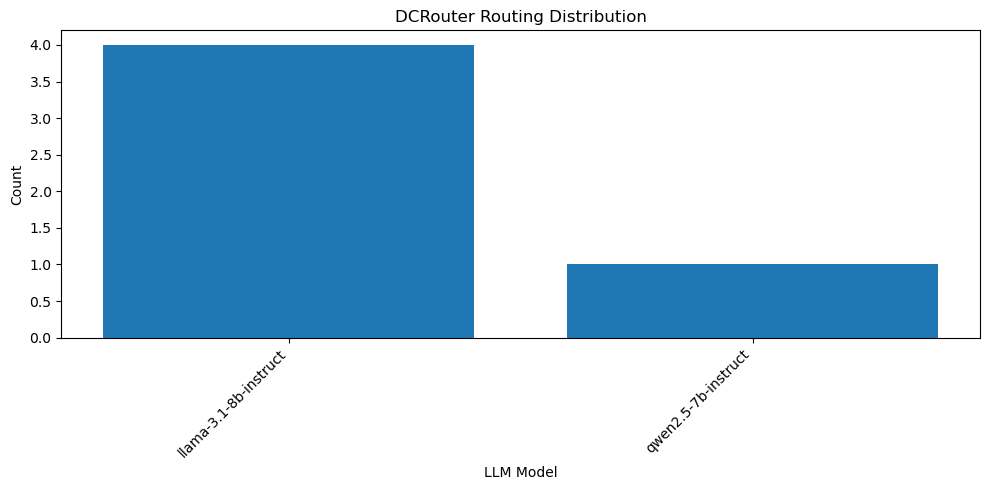

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

# Route multiple queries
results = [router.route_single(q) for q in EXAMPLE_QUERIES]

# Show distribution
model_counts = Counter(r['model_name'] for r in results)

plt.figure(figsize=(10, 5))
plt.bar(model_counts.keys(), model_counts.values())
plt.xlabel('LLM Model')
plt.ylabel('Count')
plt.title('DCRouter Routing Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. File-Based Inference

Load queries from a file and save results.

In [14]:
import json

# Load queries from a JSONL file
def load_queries_from_file(file_path):
    """Load queries from a JSONL file."""
    queries = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                queries.append(json.loads(line))
    return queries

# Save results to a JSONL file
def save_results_to_file(results, output_path):
    """Save routing results to a JSONL file."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        for result in results:
            f.write(json.dumps(result, ensure_ascii=False) + '\n')
    print(f"Results saved to: {output_path}")

# Example: Load from default query file
QUERY_FILE = "data/example_data/query_data/default_query_test.jsonl"
OUTPUT_FILE = "outputs/dcrouter_results.jsonl"

if os.path.exists(QUERY_FILE):
    # Load queries
    file_queries = load_queries_from_file(QUERY_FILE)
    print(f"Loaded {len(file_queries)} queries from: {QUERY_FILE}")
    
    # Route queries
    file_results = router.route_batch(batch=file_queries[:10])
    print(f"Routed {len(file_results)} queries")
    
    # Save results
    save_results_to_file(file_results, OUTPUT_FILE)
    
    # Show sample results
    print(f"\nSample results:")
    for i, result in enumerate(file_results[:3], 1):
        print(f"  {i}. {result.get('query', '')[:40]}... -> {result['model_name']}")
else:
    print(f"Query file not found: {QUERY_FILE}")
    print("Create a JSONL file with format: {\"query\": \"Your question\"}")

Loaded 706 queries from: data/example_data/query_data/default_query_test.jsonl
Routed 10 queries
Results saved to: outputs/dcrouter_results.jsonl

Sample results:
  1. Q: There are 4 houses in a row, numbered... -> llama-3.1-8b-instruct
  2. Q: There are 3 houses in a row, numbered... -> llama-3.1-8b-instruct
  3. Q: There are 3 houses in a row, numbered... -> llama-3.1-8b-instruct


## Summary

This notebook demonstrated:
1. Loading a trained DCRouter
2. Routing queries using transformer-based embeddings
3. Batch routing and visualization

DCRouter is effective for:
- High-accuracy routing with transformer embeddings
- Distinguishing subtle differences between queries